# Project  — Introduction to NLP
## Basic Seq2Seq Modelling with RNNs and Attention for Machine Translation

Group Members :
- [Member 1 — Nəbizadə Rəvan](#member1)
- [Member 2 — Bağırov Seyidağa](#member2)
- [Member 3 — Həsənv Mais](#member3)
- [Member 4 — Həsən Həsənzadə](#member4)
- [Member 5 — Rüfət Hüsenquliyev](#member5)


This notebook provides a **complete, modular PyTorch implementation** of:
1. A **Vanilla Seq2Seq** model (GRU encoder-decoder, no attention)
2. A **Seq2Seq + Bahdanau (Additive) Attention** model built from scratch

Attention is computed as:

$$e_{t,i} = v_a^\top \tanh(W_a s_t + U_a h_i)$$
$$\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_j \exp(e_{t,j})}$$
$$c_t = \sum_i \alpha_{t,i} h_i$$

---
**Table of Contents**
- [Section 0 — Setup & Configuration](#section-0)
- [Section 1 — Data Pipeline & Preprocessing](#section-1)
- [Section 2 — Model Architectures](#section-2)
- [Section 3 — Training Loop](#section-3)
- [Section 4 — Evaluation & Inference](#section-4)
- [Section 5 — Model Factory & Hyperparameters](#section-5)
- [Section 6 — Main Execution & Results](#section-6)


---
## Section 0 — Setup & Configuration <a id='section-0'></a>

### 0.1 Install dependencies

In [2]:
!pip install torch torchtext spacy nltk matplotlib sacrebleu
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm
!pip install nltk
import nltk
nltk.download("punkt", quiet=True)
print("Dependencies ready.")


   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   -- ------------------------------------- 0.8/14.2 MB 6.1 MB/s eta 0:00:03
   ----------- ---------------------------- 3.9/14.2 MB 11.6 MB/s eta 0:00:01
   ----------------------- ---------------- 8.4/14.2 MB 15.2 MB/s eta 0:00:01
   ---------------------------------- ----- 12.3/14.2 MB 16.3 MB/s eta 0:00:01
   ---------------------------------------- 14.2/14.2 MB 16.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/650.8 kB ? eta -:--:--
   --------------------------------------- 650.8/650.8 kB 14.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 19.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   ------------------------- -------------- 3.9/6.2 MB 19.2 MB/s eta 0:00:01
   ---------------------------------------- 6.2/6.2 MB 18.3 MB/s eta 0:00:00

   ---- ----------

### 0.2 Imports & global configuration

In [ ]:
import os
import math
import time
import random
import warnings
import itertools
from collections import Counter
from typing import List, Tuple, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ─────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ── Special token constants ─────────────────────────────────────────────────────
PAD_TOKEN = "<pad>"  # index 0  — padding token
SOS_TOKEN = "<sos>"  # index 1  — start-of-sequence
EOS_TOKEN = "<eos>"  # index 2  — end-of-sequence
UNK_TOKEN = "<unk>"  # index 3  — unknown word

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3


Using device: cpu


---
## Section 1 — Data Pipeline & Preprocessing <a id='section-1'></a>

### 1.1 Vocabulary

A bidirectional mapping between string tokens and integer indices. Special tokens `<pad>`, `<sos>`, `<eos>`, `<unk>` are always assigned indices 0–3.

In [4]:
class Vocabulary:
    """
    Maps tokens ↔ integer indices.

    Special tokens (always at fixed indices):
        0 → <pad>   (padding)
        1 → <sos>   (start-of-sequence)
        2 → <eos>   (end-of-sequence)
        3 → <unk>   (unknown word)
    """

    def __init__(self, name: str):
        self.name = name
        # token → index lookup
        self.token2idx: Dict[str, int] = {
            PAD_TOKEN: PAD_IDX,
            SOS_TOKEN: SOS_IDX,
            EOS_TOKEN: EOS_IDX,
            UNK_TOKEN: UNK_IDX,
        }
        # index → token (inverse)
        self.idx2token: Dict[int, str] = {v: k for k, v in self.token2idx.items()}

    # ── Construction ──────────────────────────────────────────────────────────
    def build_from_sentences(self, sentences: List[List[str]], min_freq: int = 2) -> None:
        """Add every token appearing >= min_freq times across all sentences."""
        counter = Counter(tok for sent in sentences for tok in sent)
        for token, freq in counter.items():
            if freq >= min_freq and token not in self.token2idx:
                idx = len(self.token2idx)
                self.token2idx[token] = idx
                self.idx2token[idx] = token
        print(f"[Vocab:{self.name}] size = {len(self)}  (min_freq={min_freq})")

    # ── Conversion helpers ────────────────────────────────────────────────────
    def encode(self, tokens: List[str]) -> List[int]:
        """Token list → index list; unknown tokens map to UNK_IDX."""
        return [self.token2idx.get(t, UNK_IDX) for t in tokens]

    def decode(self, indices: List[int], skip_special: bool = True) -> List[str]:
        """Index list → token list; optionally skip special tokens."""
        special = {PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX}
        out = []
        for idx in indices:
            tok = self.idx2token.get(idx, UNK_TOKEN)
            if skip_special and idx in special:
                continue
            out.append(tok)
        return out

    def __len__(self) -> int:
        return len(self.token2idx)

print("Vocabulary class defined.")


Vocabulary class defined.


### 1.2 Tokenisation

We try to use **SpaCy** for linguistically-aware tokenisation. If SpaCy is unavailable, a lightweight regex-based fallback is used automatically.

In [5]:
def simple_tokenize(text: str) -> List[str]:
    """
    Minimal whitespace tokeniser with punctuation splitting.
    Used as a fallback when SpaCy is unavailable.
    """
    import re
    text = text.lower().strip()
    text = re.sub(r"([?.!,])", r" \1 ", text)  # space around punctuation
    return text.split()


def get_tokenizer(lang: str):
    """
    Attempt to load a SpaCy pipeline for `lang` ('en' or 'de').
    Falls back to simple_tokenize if SpaCy is not installed / model missing.
    """
    spacy_models = {"en": "en_core_web_sm", "de": "de_core_news_sm"}
    try:
        import spacy
        nlp = spacy.load(spacy_models[lang], disable=["parser", "ner", "tagger"])
        def tokenizer(text: str) -> List[str]:
            return [tok.text.lower() for tok in nlp(text.strip())]
        print(f"SpaCy tokeniser loaded for '{lang}'")
        return tokenizer
    except Exception:
        print(f"SpaCy not available for '{lang}' — using simple tokeniser.")
        return simple_tokenize

print("Tokeniser helpers defined.")


Tokeniser helpers defined.


### 1.3 Synthetic parallel corpus

A set of 30 hand-crafted English ↔ German sentence pairs is duplicated to form a small but usable training corpus. This enables the notebook to run **entirely offline** with no downloads.

In [6]:
# 30 hand-crafted English ↔ German sentence pairs
_EN_DE_PAIRS = [
    ("a dog is running in the park",         "ein hund läuft im park"),
    ("a cat sits on the mat",                "eine katze sitzt auf der matte"),
    ("the boy is playing football",          "der junge spielt fußball"),
    ("a woman reads a book",                 "eine frau liest ein buch"),
    ("the sun is shining brightly",          "die sonne scheint hell"),
    ("two birds are flying in the sky",      "zwei vögel fliegen am himmel"),
    ("a man walks his dog",                  "ein mann geht mit seinem hund"),
    ("children are playing in the yard",     "kinder spielen im hof"),
    ("the girl is eating an apple",          "das mädchen isst einen apfel"),
    ("a horse runs across the field",        "ein pferd läuft über das feld"),
    ("the baby is sleeping",                 "das baby schläft"),
    ("a couple walks on the beach",          "ein paar geht am strand"),
    ("the dog jumps over the fence",         "der hund springt über den zaun"),
    ("a boy rides his bicycle",              "ein junge fährt fahrrad"),
    ("the cat is drinking milk",             "die katze trinkt milch"),
    ("a group of people is dancing",         "eine gruppe von menschen tanzt"),
    ("the old man is fishing",               "der alte mann fischt"),
    ("a young woman is jogging",             "eine junge frau joggt"),
    ("the children are laughing",            "die kinder lachen"),
    ("a dog is chasing a ball",              "ein hund jagt einen ball"),
    ("the farmer works in the field",        "der bauer arbeitet auf dem feld"),
    ("a bird sits on a branch",              "ein vogel sitzt auf einem ast"),
    ("the cook prepares the food",           "der koch bereitet das essen vor"),
    ("a child swims in the pool",            "ein kind schwimmt im becken"),
    ("the teacher writes on the board",      "der lehrer schreibt an die tafel"),
    ("a man paints a picture",               "ein mann malt ein bild"),
    ("the woman sings a song",               "die frau singt ein lied"),
    ("a dog plays with a toy",               "ein hund spielt mit einem spielzeug"),
    ("two men carry a large box",            "zwei männer tragen eine große schachtel"),
    ("the girl dances in the rain",          "das mädchen tanzt im regen"),
]


def generate_synthetic_corpus(
    pairs: List[Tuple[str, str]],
    n_copies: int = 30,
) -> Tuple[List[str], List[str]]:
    """
    Duplicate the hand-crafted pairs n_copies times and shuffle.
    Returns (src_sentence_list, tgt_sentence_list).
    """
    augmented = pairs * n_copies
    random.shuffle(augmented)
    src = [p[0] for p in augmented]
    tgt = [p[1] for p in augmented]
    return src, tgt

print("Synthetic corpus helper defined.")


Synthetic corpus helper defined.


### 1.4 Multi30k loader (with synthetic fallback)

In [7]:
def load_multi30k_torchtext():
    """
    Try to load Multi30k via torchtext.
    Returns (train_pairs, val_pairs, test_pairs) or None on failure.
    Each pair is a (src_str, tgt_str) tuple.
    """
    try:
        from torchtext.datasets import Multi30k
        train_data, val_data, test_data = Multi30k(
            root=".data", language_pair=("en", "de")
        )
        train_pairs = list(train_data)
        val_pairs   = list(val_data)
        test_pairs  = list(test_data)
        print(f"Multi30k loaded: train={len(train_pairs)}, "
              f"val={len(val_pairs)}, test={len(test_pairs)}")
        return train_pairs, val_pairs, test_pairs
    except Exception as e:
        print(f"Multi30k unavailable ({e}).\nFalling back to synthetic corpus.")
        return None

print("Multi30k loader defined.")


Multi30k loader defined.


### 1.5 Full preprocessing pipeline

In [8]:
def preprocess_data(
    max_len: int = 12,
    min_freq: int = 1,
    use_multi30k: bool = True,
):
    """
    End-to-end preprocessing:
        1. Load data (Multi30k or synthetic fallback)
        2. Tokenise source (English) and target (German)
        3. Filter pairs where either side exceeds max_len tokens
        4. Build source & target vocabularies
        5. Return Dataset objects and vocabularies

    Parameters
    ----------
    max_len      : maximum tokens per sentence (excluding SOS/EOS)
    min_freq     : minimum frequency for a token to enter the vocabulary
    use_multi30k : attempt to download Multi30k before falling back

    Returns
    -------
    train_ds, val_ds, test_ds : TranslationDataset
    src_vocab, tgt_vocab      : Vocabulary
    """
    # ── Step 1: load raw sentence strings ──────────────────────────────────────
    multi30k_result = load_multi30k_torchtext() if use_multi30k else None

    if multi30k_result is not None:
        raw_train, raw_val, raw_test = multi30k_result
        src_train_raw = [p[0] for p in raw_train]
        tgt_train_raw = [p[1] for p in raw_train]
        src_val_raw   = [p[0] for p in raw_val]
        tgt_val_raw   = [p[1] for p in raw_val]
        src_test_raw  = [p[0] for p in raw_test]
        tgt_test_raw  = [p[1] for p in raw_test]
    else:
        # Synthetic fallback: create three splits from hand-crafted pairs
        src_all, tgt_all = generate_synthetic_corpus(_EN_DE_PAIRS, n_copies=30)
        n       = len(src_all)
        n_train = int(0.70 * n)
        n_val   = int(0.15 * n)
        src_train_raw = src_all[:n_train];          tgt_train_raw = tgt_all[:n_train]
        src_val_raw   = src_all[n_train:n_train+n_val]; tgt_val_raw = tgt_all[n_train:n_train+n_val]
        src_test_raw  = src_all[n_train+n_val:];   tgt_test_raw  = tgt_all[n_train+n_val:]

    # ── Step 2: tokenise & filter by length ────────────────────────────────────
    src_tok = get_tokenizer("en")
    tgt_tok = get_tokenizer("de")

    def tokenise_and_filter(src_raws, tgt_raws):
        src_out, tgt_out = [], []
        for s, t in zip(src_raws, tgt_raws):
            s_tok = src_tok(s)
            t_tok = tgt_tok(t)
            if len(s_tok) <= max_len and len(t_tok) <= max_len:
                src_out.append(s_tok)
                tgt_out.append(t_tok)
        return src_out, tgt_out

    src_train, tgt_train = tokenise_and_filter(src_train_raw, tgt_train_raw)
    src_val,   tgt_val   = tokenise_and_filter(src_val_raw,   tgt_val_raw)
    src_test,  tgt_test  = tokenise_and_filter(src_test_raw,  tgt_test_raw)

    print(f"After length filter (max_len={max_len}): "
          f"train={len(src_train)}, val={len(src_val)}, test={len(src_test)}")

    # ── Step 3: build vocabularies from training data ──────────────────────────
    src_vocab = Vocabulary("EN")
    src_vocab.build_from_sentences(src_train, min_freq=min_freq)

    tgt_vocab = Vocabulary("DE")
    tgt_vocab.build_from_sentences(tgt_train, min_freq=min_freq)

    # ── Step 4: wrap in Dataset objects ────────────────────────────────────────
    train_ds = TranslationDataset(src_train, tgt_train, src_vocab, tgt_vocab)
    val_ds   = TranslationDataset(src_val,   tgt_val,   src_vocab, tgt_vocab)
    test_ds  = TranslationDataset(src_test,  tgt_test,  src_vocab, tgt_vocab)

    return train_ds, val_ds, test_ds, src_vocab, tgt_vocab

print("preprocess_data() defined.")


preprocess_data() defined.


### 1.6 PyTorch Dataset & DataLoader

In [9]:
class TranslationDataset(Dataset):
    """
    Stores vocabulary-encoded sentence pairs.

    Each item is a tuple (src_ids, tgt_ids) with SOS and EOS already appended.
    Padding is handled lazily inside the collate function at batch-creation time.
    """
    def __init__(self, src_sentences, tgt_sentences, src_vocab, tgt_vocab):
        assert len(src_sentences) == len(tgt_sentences)
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.data: List[Tuple[List[int], List[int]]] = []

        for src_toks, tgt_toks in zip(src_sentences, tgt_sentences):
            # Wrap every sentence with SOS at the start and EOS at the end
            src_ids = [SOS_IDX] + src_vocab.encode(src_toks) + [EOS_IDX]
            tgt_ids = [SOS_IDX] + tgt_vocab.encode(tgt_toks) + [EOS_IDX]
            self.data.append((src_ids, tgt_ids))

    def __len__(self):  return len(self.data)
    def __getitem__(self, idx): return self.data[idx]


def collate_fn(batch):
    """
    Pad sequences within a batch to the longest sequence in that batch.

    Sorts the batch by descending source length (required for
    pack_padded_sequence inside the encoder).

    Returns
    -------
    src_padded  : [B, T_src]   padded source token indices
    tgt_padded  : [B, T_tgt]   padded target token indices
    src_lengths : [B]          true (un-padded) source lengths
    tgt_lengths : [B]          true (un-padded) target lengths
    """
    src_seqs, tgt_seqs = zip(*batch)

    src_lengths = torch.tensor([len(s) for s in src_seqs])
    tgt_lengths = torch.tensor([len(t) for t in tgt_seqs])

    # Sort batch by descending source length
    src_lengths, sort_idx = src_lengths.sort(descending=True)
    src_seqs = [src_seqs[i] for i in sort_idx]
    tgt_seqs = [tgt_seqs[i] for i in sort_idx]
    tgt_lengths = tgt_lengths[sort_idx]

    max_src = src_lengths[0].item()
    max_tgt = tgt_lengths.max().item()

    # Allocate fully-padded tensors, then fill in the true content
    src_padded = torch.full((len(src_seqs), max_src), PAD_IDX, dtype=torch.long)
    tgt_padded = torch.full((len(tgt_seqs), max_tgt), PAD_IDX, dtype=torch.long)

    for i, (s, t) in enumerate(zip(src_seqs, tgt_seqs)):
        src_padded[i, :len(s)] = torch.tensor(s, dtype=torch.long)
        tgt_padded[i, :len(t)] = torch.tensor(t, dtype=torch.long)

    return src_padded, tgt_padded, src_lengths, tgt_lengths


def build_dataloaders(train_ds, val_ds, test_ds, batch_size=64):
    """Build and return DataLoaders for all three splits."""
    kw = dict(collate_fn=collate_fn, pin_memory=(DEVICE.type == "cuda"))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw)
    return train_loader, val_loader, test_loader

print("Dataset and DataLoader helpers defined.")


Dataset and DataLoader helpers defined.


---
## Section 2 — Model Architectures <a id='section-2'></a>

### 2-A Encoder

A single-layer GRU encoder that reads source tokens and outputs:
- **All hidden states** $H = [h_1, h_2, \dots, h_T]$ — shape `[B, T_src, hidden_dim]`
- **Final hidden state** $h_T$ — shape `[n_layers, B, hidden_dim]`

`pack_padded_sequence` ensures padding tokens do not pollute the hidden states.

In [10]:
class Encoder(nn.Module):
    """
    GRU encoder — processes source tokens and returns all hidden states.

    Shapes at a glance:
        Input  src        : [B, T_src]
        Output enc_outputs: [B, T_src, hidden_dim]   (all hidden states H)
        Output hidden     : [n_layers, B, hidden_dim] (final state h_T)
    """

    def __init__(self, src_vocab_size, embed_dim, hidden_dim,
                 n_layers=1, dropout=0.3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers   = n_layers

        # Token indices → dense embedding vectors
        self.embedding = nn.Embedding(src_vocab_size, embed_dim, padding_idx=PAD_IDX)

        # GRU processes the full embedded sequence
        self.rnn = nn.GRU(
            embed_dim, hidden_dim,
            num_layers=n_layers,
            batch_first=True,                          # tensors shaped [B, T, *]
            bidirectional=False,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lengths):
        # src: [B, T_src]  |  src_lengths: [B]

        embedded = self.dropout(self.embedding(src))
        # embedded: [B, T_src, embed_dim]

        # Pack → removes padding from the computation graph
        packed    = pack_padded_sequence(embedded, src_lengths.cpu(),
                                         batch_first=True, enforce_sorted=True)
        packed_out, hidden = self.rnn(packed)
        # hidden: [n_layers, B, hidden_dim]

        # Unpack → re-introduces padding zeros for downstream use
        enc_outputs, _ = pad_packed_sequence(packed_out, batch_first=True)
        # enc_outputs: [B, T_src, hidden_dim]

        return enc_outputs, hidden

print("Encoder defined.")


Encoder defined.


### 2-B Vanilla Decoder (no attention)

Uses **only** the final encoder hidden state $h_T$ as its initial hidden state. The source is completely compressed into a single fixed-length vector — the key limitation of vanilla Seq2Seq.

In [11]:
class VanillaDecoder(nn.Module):
    """
    GRU decoder without attention.

    At each step t:
        embed(token_t) → GRU(hidden_{t-1}) → Linear → logits_t

    The entire source meaning is compressed into the initial hidden state h_T.
    """

    def __init__(self, tgt_vocab_size, embed_dim, hidden_dim,
                 n_layers=1, dropout=0.3):
        super().__init__()
        self.tgt_vocab_size = tgt_vocab_size
        self.hidden_dim     = hidden_dim
        self.n_layers       = n_layers

        self.embedding = nn.Embedding(tgt_vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn       = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers,
                                batch_first=True,
                                dropout=dropout if n_layers > 1 else 0.0)
        self.fc_out    = nn.Linear(hidden_dim, tgt_vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward_step(self, tgt_token, hidden):
        """Single decoding step → (logits [B, V], hidden [n_layers, B, H])."""
        embedded = self.dropout(self.embedding(tgt_token.unsqueeze(1)))
        # embedded: [B, 1, embed_dim]

        output, hidden = self.rnn(embedded, hidden)
        # output: [B, 1, hidden_dim]

        logits = self.fc_out(output.squeeze(1))
        # logits: [B, tgt_vocab_size]
        return logits, hidden

    def forward(self, tgt, encoder_hidden, teacher_forcing_ratio=0.5):
        """
        Decode a full target sequence with optional teacher forcing.

        Returns
        -------
        all_logits : [B, T_tgt - 1, tgt_vocab_size]
        """
        B, T_tgt = tgt.shape
        hidden   = encoder_hidden   # initialise with encoder's final state h_T
        all_logits = torch.zeros(B, T_tgt - 1, self.tgt_vocab_size).to(tgt.device)

        input_token = tgt[:, 0]  # first input is always <sos>

        for t in range(1, T_tgt):
            logits, hidden = self.forward_step(input_token, hidden)
            all_logits[:, t - 1, :] = logits

            # Teacher forcing: use ground-truth vs model prediction as next input
            use_teacher = random.random() < teacher_forcing_ratio
            input_token = tgt[:, t] if use_teacher else logits.argmax(dim=-1)

        return all_logits  # [B, T_tgt-1, V]

print("VanillaDecoder defined.")


VanillaDecoder defined.


### 2-C Bahdanau (Additive) Attention — from scratch

Implements the full attention mechanism:

$$e_{t,i} = v_a^\top \tanh(W_a s_t + U_a h_i) \quad \text{(alignment scores)}$$
$$\alpha_{t,i} = \text{softmax}(e_{t,i}) \quad \text{(attention weights)}$$
$$c_t = \sum_i \alpha_{t,i} h_i \quad \text{(context vector)}$$

where $s_t$ is the decoder state and $h_i$ are encoder hidden states.

In [12]:
class BahdanauAttention(nn.Module):
    """
    Additive (Bahdanau) attention — built from scratch.

    Learnable parameters:
        W_a : projects the decoder hidden state s_t  → [B, attn_dim]
        U_a : projects each encoder hidden state h_i → [B, T_src, attn_dim]
        v_a : scoring vector                         → scalar per position

    All three are bias-free linear layers (matching the original paper).
    """

    def __init__(self, hidden_dim: int, attn_dim: int):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.attn_dim   = attn_dim

        # W_a * s_t  :  [B, hidden_dim] → [B, attn_dim]
        self.W_a = nn.Linear(hidden_dim, attn_dim, bias=False)

        # U_a * h_i  :  [B, T_src, hidden_dim] → [B, T_src, attn_dim]
        self.U_a = nn.Linear(hidden_dim, attn_dim, bias=False)

        # v_a^T * (·) : [B, T_src, attn_dim] → [B, T_src, 1] → [B, T_src]
        self.v_a = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, s_t, H, src_mask=None):
        """
        Parameters
        ----------
        s_t      : [B, hidden_dim]        decoder hidden state at step t
        H        : [B, T_src, hidden_dim] all encoder hidden states
        src_mask : [B, T_src]  bool, True at PAD positions (masked to -inf)

        Returns
        -------
        c_t   : [B, hidden_dim]  context vector
        alpha : [B, T_src]       attention weights (sum to 1 along T_src)
        """
        # ── Alignment scores e_{t,i} ──────────────────────────────────────────
        W_s = self.W_a(s_t).unsqueeze(1)    # [B, 1, attn_dim]  (broadcast over T_src)
        U_h = self.U_a(H)                   # [B, T_src, attn_dim]

        # e_{t,i} = v_a^T * tanh( W_a*s_t + U_a*h_i )
        energy = self.v_a(torch.tanh(W_s + U_h)).squeeze(-1)   # [B, T_src]

        # ── Mask padding tokens (set their score to -∞ before softmax) ────────
        if src_mask is not None:
            energy = energy.masked_fill(src_mask, float("-inf"))

        # ── Softmax → attention weights α_{t,i} ───────────────────────────────
        alpha = F.softmax(energy, dim=-1)   # [B, T_src]  (sums to 1)

        # ── Context vector c_t = Σ_i α_{t,i} * h_i ───────────────────────────
        # alpha.unsqueeze(1) : [B, 1, T_src]
        # H                  : [B, T_src, hidden_dim]
        # bmm result         : [B, 1, hidden_dim]  → squeeze → [B, hidden_dim]
        c_t = torch.bmm(alpha.unsqueeze(1), H).squeeze(1)

        return c_t, alpha

print("BahdanauAttention defined.")


BahdanauAttention defined.


### 2-D Attention-Based Decoder

At every decoding step:
1. Compute $c_t$ via Bahdanau attention over all encoder states
2. Concatenate the token embedding with $c_t$
3. Feed the combined input to the GRU
4. Project `[GRU output ++ c_t]` to vocabulary logits

In [13]:
class AttentionDecoder(nn.Module):
    """
    GRU decoder with Bahdanau attention.

    At each step t:
        c_t, alpha ← Attention(s_{t-1}, H)
        rnn_input  ← [embed(token_t) ; c_t]
        s_t, _     ← GRU(rnn_input, s_{t-1})
        logits_t   ← Linear([s_t ; c_t])
    """

    def __init__(self, tgt_vocab_size, embed_dim, hidden_dim,
                 attn_dim, n_layers=1, dropout=0.3):
        super().__init__()
        self.tgt_vocab_size = tgt_vocab_size
        self.hidden_dim     = hidden_dim
        self.n_layers       = n_layers

        self.embedding = nn.Embedding(tgt_vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention  = BahdanauAttention(hidden_dim, attn_dim)

        # GRU input = embedding (embed_dim) concatenated with context (hidden_dim)
        self.rnn = nn.GRU(embed_dim + hidden_dim, hidden_dim,
                          num_layers=n_layers, batch_first=True,
                          dropout=dropout if n_layers > 1 else 0.0)

        # Output projection: [GRU output || context] → vocabulary
        self.fc_out  = nn.Linear(hidden_dim + hidden_dim, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, tgt_token, hidden, H, src_mask=None):
        """
        Single attention-based decoding step.

        Returns
        -------
        logits : [B, tgt_vocab_size]
        hidden : [n_layers, B, hidden_dim]
        alpha  : [B, T_src]   attention weights (for visualisation)
        """
        embedded = self.dropout(self.embedding(tgt_token.unsqueeze(1)))
        # embedded: [B, 1, embed_dim]

        # Use top-layer hidden state to compute attention
        s_t = hidden[-1]   # [B, hidden_dim]
        c_t, alpha = self.attention(s_t, H, src_mask)
        # c_t   : [B, hidden_dim]
        # alpha : [B, T_src]

        # Concatenate embedding and context before passing to GRU
        rnn_input = torch.cat([embedded, c_t.unsqueeze(1)], dim=-1)
        # rnn_input: [B, 1, embed_dim + hidden_dim]

        output, hidden = self.rnn(rnn_input, hidden)
        # output: [B, 1, hidden_dim]

        # Combine GRU output with context for richer projection
        combined = torch.cat([output.squeeze(1), c_t], dim=-1)
        # combined: [B, hidden_dim * 2]

        logits = self.fc_out(combined)
        # logits: [B, tgt_vocab_size]

        return logits, hidden, alpha

    def forward(self, tgt, enc_outputs, enc_hidden, src_mask,
                teacher_forcing_ratio=0.5):
        """
        Full sequence decoding with teacher forcing.

        Returns
        -------
        all_logits    : [B, T_tgt - 1, tgt_vocab_size]
        all_attention : [B, T_tgt - 1, T_src]
        """
        B, T_tgt = tgt.shape
        T_src    = enc_outputs.shape[1]
        hidden   = enc_hidden

        all_logits    = torch.zeros(B, T_tgt - 1, self.tgt_vocab_size).to(tgt.device)
        all_attention = torch.zeros(B, T_tgt - 1, T_src).to(tgt.device)

        input_token = tgt[:, 0]  # <sos>

        for t in range(1, T_tgt):
            logits, hidden, alpha = self.forward_step(input_token, hidden,
                                                      enc_outputs, src_mask)
            all_logits[:, t - 1, :]    = logits
            all_attention[:, t - 1, :] = alpha

            use_teacher = random.random() < teacher_forcing_ratio
            input_token = tgt[:, t] if use_teacher else logits.argmax(dim=-1)

        return all_logits, all_attention

print("AttentionDecoder defined.")


AttentionDecoder defined.


### 2-E Full Seq2Seq wrappers

In [14]:
class VanillaSeq2Seq(nn.Module):
    """End-to-end Vanilla Seq2Seq: Encoder → VanillaDecoder."""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, src_lengths, teacher_forcing_ratio=0.5):
        # src: [B, T_src] | tgt: [B, T_tgt] | src_lengths: [B]
        _, enc_hidden = self.encoder(src, src_lengths)
        logits = self.decoder(tgt, enc_hidden, teacher_forcing_ratio)
        return logits  # [B, T_tgt-1, V]


class AttentionSeq2Seq(nn.Module):
    """End-to-end Attention Seq2Seq: Encoder → BahdanauAttention → AttentionDecoder."""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    @staticmethod
    def make_src_mask(src, src_lengths):
        """
        Create boolean mask: True at padding positions (will be set to -inf
        before softmax so attention ignores them).
        mask: [B, T_src]
        """
        B, T_src = src.shape
        mask = torch.arange(T_src, device=src.device).unsqueeze(0) >=                src_lengths.to(src.device).unsqueeze(1)
        return mask  # [B, T_src]

    def forward(self, src, tgt, src_lengths, teacher_forcing_ratio=0.5):
        src_mask = self.make_src_mask(src, src_lengths)
        enc_outputs, enc_hidden = self.encoder(src, src_lengths)
        logits, attention = self.decoder(
            tgt, enc_outputs, enc_hidden, src_mask, teacher_forcing_ratio
        )
        return logits, attention  # [B, T-1, V], [B, T-1, T_src]

print("VanillaSeq2Seq and AttentionSeq2Seq defined.")


VanillaSeq2Seq and AttentionSeq2Seq defined.


---
## Section 3 — Training Loop (with Teacher Forcing) <a id='section-3'></a>

**Teacher forcing** replaces the model's own predicted token with the ground-truth token as input for the next decoding step, controlled by `teacher_forcing_ratio`:
- Ratio = 1.0 → always use ground truth (fastest learning, but training/inference mismatch)
- Ratio = 0.0 → always use model's own prediction (slower but more robust)
- Ratio = 0.5 → stochastic mix (recommended default)

In [15]:
def count_parameters(model):
    """Count trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, optimizer, criterion, clip,
                    teacher_forcing_ratio, is_attention):
    """
    Train for one epoch; return mean batch loss.

    Uses:
    - CrossEntropyLoss ignoring PAD_IDX
    - Gradient clipping (prevents exploding gradients in RNNs)
    """
    model.train()
    total_loss = 0.0

    for src, tgt, src_len, _ in loader:
        src, tgt, src_len = src.to(DEVICE), tgt.to(DEVICE), src_len.to(DEVICE)
        optimizer.zero_grad()

        if is_attention:
            logits, _ = model(src, tgt, src_len, teacher_forcing_ratio)
        else:
            logits    = model(src, tgt, src_len, teacher_forcing_ratio)

        # logits: [B, T_tgt-1, V]   tgt[:,1:]: [B, T_tgt-1]
        B, T, V = logits.shape
        loss = criterion(logits.reshape(B * T, V), tgt[:, 1:].reshape(B * T))

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_loss(model, loader, criterion, is_attention):
    """Evaluate model on a DataLoader; return mean loss (no gradients)."""
    model.eval()
    total_loss = 0.0

    for src, tgt, src_len, _ in loader:
        src, tgt, src_len = src.to(DEVICE), tgt.to(DEVICE), src_len.to(DEVICE)

        if is_attention:
            logits, _ = model(src, tgt, src_len, teacher_forcing_ratio=0.0)
        else:
            logits    = model(src, tgt, src_len, teacher_forcing_ratio=0.0)

        B, T, V = logits.shape
        loss = criterion(logits.reshape(B * T, V), tgt[:, 1:].reshape(B * T))
        total_loss += loss.item()

    return total_loss / len(loader)


def train_model(model, train_loader, val_loader, n_epochs, lr, clip,
                teacher_forcing_ratio, is_attention, model_name, patience=5):
    """
    Full training loop with:
        - Adam optimiser
        - CrossEntropyLoss (PAD tokens ignored)
        - Gradient clipping
        - Early stopping on validation loss
        - Best checkpoint saved to disk

    Returns
    -------
    train_losses, val_losses : List[float]
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    best_val  = float("inf")
    patience_counter = 0
    train_losses, val_losses = [], []
    ckpt_path = f"best_{model_name}.pt"

    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"  Trainable parameters: {count_parameters(model):,}")
    print(f"{'='*60}")

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        tr  = train_one_epoch(model, train_loader, optimizer, criterion,
                               clip, teacher_forcing_ratio, is_attention)
        val = evaluate_loss(model, val_loader, criterion, is_attention)
        train_losses.append(tr)
        val_losses.append(val)

        print(f"Epoch {epoch:3d}/{n_epochs}  "
              f"Train {tr:.4f} (PPL {math.exp(tr):.2f})  "
              f"Val {val:.4f} (PPL {math.exp(val):.2f})  "
              f"{time.time()-t0:.1f}s")

        # ── Early stopping ─────────────────────────────────────────────────────
        if val < best_val:
            best_val = val
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stop — no improvement for {patience} epochs.")
                break

    # Restore the best checkpoint
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    print(f"  Best validation loss: {best_val:.4f}")
    return train_losses, val_losses

print("Training functions defined.")


Training functions defined.


---
## Section 4 — Evaluation & Inference <a id='section-4'></a>

### 4.1 Greedy decoding inference

Translates a raw English sentence token-by-token using greedy (argmax) decoding — no beam search.

In [16]:
@torch.no_grad()
def translate_sentence(model, sentence, src_vocab, tgt_vocab, src_tok_fn,
                        max_len=50, is_attention=False):
    """
    Translate a raw English sentence via greedy decoding.

    Parameters
    ----------
    model        : trained Seq2Seq model
    sentence     : raw English string
    src_vocab    : source Vocabulary
    tgt_vocab    : target Vocabulary
    src_tok_fn   : tokeniser function
    max_len      : maximum decoding steps
    is_attention : True if model is AttentionSeq2Seq

    Returns
    -------
    translation  : list of German token strings
    attn_weights : Tensor [T_tgt, T_src] or None
    """
    model.eval()

    # Tokenise and encode the source sentence
    tokens     = src_tok_fn(sentence.lower())
    src_ids    = [SOS_IDX] + src_vocab.encode(tokens) + [EOS_IDX]
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
    # src_tensor: [1, T_src]
    src_len    = torch.tensor([len(src_ids)])

    # ── Encode ────────────────────────────────────────────────────────────────
    if is_attention:
        enc_outputs, enc_hidden = model.encoder(src_tensor, src_len)
        src_mask = AttentionSeq2Seq.make_src_mask(src_tensor, src_len)
    else:
        _, enc_hidden = model.encoder(src_tensor, src_len)

    # ── Greedy decode step-by-step ────────────────────────────────────────────
    hidden      = enc_hidden
    input_token = torch.tensor([SOS_IDX], dtype=torch.long).to(DEVICE)
    translation = []
    attn_list   = []

    for _ in range(max_len):
        if is_attention:
            logits, hidden, alpha = model.decoder.forward_step(
                input_token, hidden, enc_outputs, src_mask
            )
            attn_list.append(alpha.squeeze(0).cpu())  # [T_src]
        else:
            logits, hidden = model.decoder.forward_step(input_token, hidden)

        pred_token = logits.argmax(dim=-1).item()
        if pred_token == EOS_IDX:
            break

        translation.append(tgt_vocab.idx2token.get(pred_token, UNK_TOKEN))
        input_token = torch.tensor([pred_token], dtype=torch.long).to(DEVICE)

    attn_matrix = torch.stack(attn_list, dim=0) if attn_list else None
    # attn_matrix: [T_tgt, T_src] or None

    return translation, attn_matrix

print("translate_sentence() defined.")


translate_sentence() defined.


### 4.2 Corpus-level BLEU evaluation

Computes **BLEU-4** (corpus level) using NLTK with add-1 smoothing to handle short sentences.

In [17]:
@torch.no_grad()
def compute_bleu(model, dataset, src_vocab, tgt_vocab, src_tok_fn,
                 is_attention, max_samples=300):
    """
    Compute corpus-level BLEU-4 score on a translation dataset.

    Parameters
    ----------
    model        : trained Seq2Seq model
    dataset      : TranslationDataset (test split)
    max_samples  : cap the number of sentences evaluated (for speed)

    Returns
    -------
    bleu_score : float in [0, 100]
    """
    model.eval()
    hypotheses, references = [], []

    n_samples = min(len(dataset), max_samples)
    indices   = random.sample(range(len(dataset)), n_samples)

    for idx in indices:
        src_ids, tgt_ids = dataset[idx]

        # Convert source indices back to a string for translate_sentence
        src_tokens = src_vocab.decode(src_ids, skip_special=True)
        src_str    = " ".join(src_tokens)

        # Reference: target tokens without special tokens
        ref_tokens = tgt_vocab.decode(tgt_ids, skip_special=True)

        # Hypothesis from greedy decoding
        hyp_tokens, _ = translate_sentence(
            model, src_str, src_vocab, tgt_vocab, src_tok_fn, is_attention=is_attention
        )

        hypotheses.append(hyp_tokens)
        references.append([ref_tokens])   # corpus_bleu expects list-of-lists

    smoother = SmoothingFunction().method1
    score    = corpus_bleu(references, hypotheses, smoothing_function=smoother)
    return score * 100  # scale to [0, 100]

print("compute_bleu() defined.")


compute_bleu() defined.


### 4.3 Attention heatmap visualisation

Plots the attention weight matrix $\alpha$ as a heatmap. Rows are decoding steps (output tokens), columns are source positions.

In [18]:
def plot_attention(attention, src_tokens, tgt_tokens,
                   title="Bahdanau Attention Heatmap", save_path=None):
    """
    Plot attention weights as a colour heatmap.

    Parameters
    ----------
    attention  : Tensor [T_tgt, T_src]
    src_tokens : list of source token strings (with SOS/EOS labels)
    tgt_tokens : list of generated target token strings
    """
    attn_np = attention.numpy()   # [T_tgt, T_src]

    fig, ax = plt.subplots(figsize=(max(8, len(src_tokens)),
                                    max(5, len(tgt_tokens))))
    im = ax.matshow(attn_np, cmap="viridis", aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha="left", fontsize=11)
    ax.set_yticklabels(tgt_tokens, fontsize=11)
    ax.set_xlabel("Source (English)", fontsize=13)
    ax.set_ylabel("Target (German) — decoding steps", fontsize=13)
    ax.set_title(title, fontsize=14, pad=20)

    # Annotate cells with α values
    for row in range(attn_np.shape[0]):
        for col in range(attn_np.shape[1]):
            val   = attn_np[row, col]
            color = "white" if val < 0.5 else "black"
            ax.text(col, row, f"{val:.2f}", ha="center", va="center",
                    fontsize=7, color=color)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_loss_curves(v_tr, v_val, a_tr, a_val, save_path=None):
    """Side-by-side training/validation loss curves for both models."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (tr, va, name) in zip(
        axes,
        [(v_tr, v_val, "Vanilla Seq2Seq"),
         (a_tr, a_val, "Seq2Seq + Bahdanau Attention")]
    ):
        ep = range(1, len(tr) + 1)
        ax.plot(ep, tr, "b-o", markersize=4, label="Train Loss")
        ax.plot(ep, va, "r-s", markersize=4, label="Val Loss")
        ax.set_title(name, fontsize=13)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
        ax.legend(); ax.grid(True, alpha=0.3)
    fig.suptitle("Learning Curves Comparison", fontsize=15)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_bleu_comparison(vanilla_bleu, attn_bleu, save_path=None):
    """Bar chart comparing BLEU scores of the two models."""
    fig, ax = plt.subplots(figsize=(7, 5))
    models  = ["Vanilla Seq2Seq", "Seq2Seq +\nBahdanau Attn"]
    scores  = [vanilla_bleu, attn_bleu]
    colors  = ["#4C72B0", "#DD8452"]
    bars    = ax.bar(models, scores, color=colors, width=0.5, edgecolor="black")
    for bar, sc in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{sc:.2f}", ha="center", va="bottom", fontsize=13, fontweight="bold")
    ax.set_ylabel("Corpus BLEU Score", fontsize=12)
    ax.set_title("BLEU Score Comparison (Test Set)", fontsize=14)
    ax.set_ylim(0, max(scores) * 1.3 + 1)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

print("Plotting functions defined.")


Plotting functions defined.


---
## Section 5 — Model Factory & Hyperparameters <a id='section-5'></a>

Edit `HPARAMS` to configure the experiment without touching model code.

In [19]:
HPARAMS = dict(
    # ── Data ──────────────────────────────────────────────────────────────────
    max_len           = 12,    # filter sentences longer than this (tokens)
    min_freq          = 1,     # minimum token frequency for vocabulary inclusion
    batch_size        = 64,

    # ── Model dimensions ──────────────────────────────────────────────────────
    embed_dim         = 128,   # token embedding size
    hidden_dim        = 256,   # GRU hidden state size
    attn_dim          = 128,   # internal dimension for W_a / U_a projections
    n_layers          = 1,     # number of GRU layers
    dropout           = 0.3,

    # ── Training ──────────────────────────────────────────────────────────────
    n_epochs          = 20,
    lr                = 1e-3,
    clip              = 1.0,   # gradient clipping norm
    teacher_forcing   = 0.5,   # probability of feeding ground-truth next token
    patience          = 5,     # early-stopping patience (epochs)

    # ── Evaluation ────────────────────────────────────────────────────────────
    max_bleu_samples  = 300,   # cap for speed; set to None for full test set
)


def build_vanilla_model(src_vocab, tgt_vocab):
    """Build, initialise, and return a VanillaSeq2Seq model."""
    hp = HPARAMS
    encoder = Encoder(len(src_vocab), hp["embed_dim"], hp["hidden_dim"],
                      hp["n_layers"], hp["dropout"])
    decoder = VanillaDecoder(len(tgt_vocab), hp["embed_dim"], hp["hidden_dim"],
                             hp["n_layers"], hp["dropout"])
    model = VanillaSeq2Seq(encoder, decoder).to(DEVICE)
    # Xavier uniform init for all weight matrices
    for p in model.parameters():
        if p.dim() > 1: nn.init.xavier_uniform_(p)
    return model


def build_attention_model(src_vocab, tgt_vocab):
    """Build, initialise, and return an AttentionSeq2Seq model."""
    hp = HPARAMS
    encoder = Encoder(len(src_vocab), hp["embed_dim"], hp["hidden_dim"],
                      hp["n_layers"], hp["dropout"])
    decoder = AttentionDecoder(len(tgt_vocab), hp["embed_dim"], hp["hidden_dim"],
                               hp["attn_dim"], hp["n_layers"], hp["dropout"])
    model = AttentionSeq2Seq(encoder, decoder).to(DEVICE)
    for p in model.parameters():
        if p.dim() > 1: nn.init.xavier_uniform_(p)
    return model

print("HPARAMS and model factory functions defined.")


HPARAMS and model factory functions defined.


---
## Section 6 — Main Execution & Results <a id='section-6'></a>

### Step 1 — Preprocess data

In [20]:
hp = HPARAMS

print("=" * 60)
print("  Seq2Seq NLP Project — Machine Translation (EN → DE)")
print("=" * 60)
print(f"  Device     : {DEVICE}")
print(f"  Max length : {hp['max_len']} tokens")
print(f"  Batch size : {hp['batch_size']}")
print(f"  Epochs     : {hp['n_epochs']}")
print("=" * 60)

train_ds, val_ds, test_ds, src_vocab, tgt_vocab = preprocess_data(
    max_len=hp["max_len"],
    min_freq=hp["min_freq"],
    use_multi30k=True,   # set False to force synthetic corpus
)

train_loader, val_loader, test_loader = build_dataloaders(
    train_ds, val_ds, test_ds, batch_size=hp["batch_size"]
)

# Tokeniser for inference (must match the one used during preprocessing)
src_tok_fn = get_tokenizer("en")

print(f"\nSource vocabulary size : {len(src_vocab):,}")
print(f"Target vocabulary size : {len(tgt_vocab):,}")
print(f"Training batches       : {len(train_loader)}")


  Seq2Seq NLP Project — Machine Translation (EN → DE)
  Device     : cpu
  Max length : 12 tokens
  Batch size : 64
  Epochs     : 20
Multi30k unavailable (TranslationDataset.__init__() missing 3 required positional arguments: 'path', 'exts', and 'fields').
Falling back to synthetic corpus.
SpaCy tokeniser loaded for 'en'
SpaCy tokeniser loaded for 'de'
After length filter (max_len=12): train=630, val=135, test=135
[Vocab:EN] size = 90  (min_freq=1)
[Vocab:DE] size = 93  (min_freq=1)
SpaCy tokeniser loaded for 'en'

Source vocabulary size : 90
Target vocabulary size : 93
Training batches       : 10


### Step 2 — Train Vanilla Seq2Seq

In [21]:
vanilla_model = build_vanilla_model(src_vocab, tgt_vocab)

vanilla_train_losses, vanilla_val_losses = train_model(
    model                 = vanilla_model,
    train_loader          = train_loader,
    val_loader            = val_loader,
    n_epochs              = hp["n_epochs"],
    lr                    = hp["lr"],
    clip                  = hp["clip"],
    teacher_forcing_ratio = hp["teacher_forcing"],
    is_attention          = False,
    model_name            = "vanilla_seq2seq",
    patience              = hp["patience"],
)



  Training: vanilla_seq2seq
  Trainable parameters: 640,221
Epoch   1/20  Train 4.3363 (PPL 76.42)  Val 3.8714 (PPL 48.01)  0.4s
Epoch   2/20  Train 3.7282 (PPL 41.61)  Val 3.5561 (PPL 35.03)  0.3s
Epoch   3/20  Train 3.3626 (PPL 28.86)  Val 3.2330 (PPL 25.36)  0.3s
Epoch   4/20  Train 3.0590 (PPL 21.31)  Val 2.9370 (PPL 18.86)  0.4s
Epoch   5/20  Train 2.7276 (PPL 15.30)  Val 2.6573 (PPL 14.26)  0.3s
Epoch   6/20  Train 2.4135 (PPL 11.17)  Val 2.3455 (PPL 10.44)  0.3s
Epoch   7/20  Train 2.1070 (PPL 8.22)  Val 2.0613 (PPL 7.86)  0.3s
Epoch   8/20  Train 1.8037 (PPL 6.07)  Val 1.7728 (PPL 5.89)  0.3s
Epoch   9/20  Train 1.4703 (PPL 4.35)  Val 1.3851 (PPL 4.00)  0.3s
Epoch  10/20  Train 1.2013 (PPL 3.32)  Val 1.1454 (PPL 3.14)  0.3s
Epoch  11/20  Train 0.9345 (PPL 2.55)  Val 0.9045 (PPL 2.47)  0.3s
Epoch  12/20  Train 0.7127 (PPL 2.04)  Val 0.7023 (PPL 2.02)  0.4s
Epoch  13/20  Train 0.5072 (PPL 1.66)  Val 0.5546 (PPL 1.74)  0.4s
Epoch  14/20  Train 0.3991 (PPL 1.49)  Val 0.4043 (PPL 1

### Step 3 — Evaluate Vanilla BLEU

In [22]:
vanilla_bleu = compute_bleu(
    model        = vanilla_model,
    dataset      = test_ds,
    src_vocab    = src_vocab,
    tgt_vocab    = tgt_vocab,
    src_tok_fn   = src_tok_fn,
    is_attention = False,
    max_samples  = hp["max_bleu_samples"],
)
print(f"Vanilla Seq2Seq  →  BLEU = {vanilla_bleu:.2f}")


Vanilla Seq2Seq  →  BLEU = 99.15


### Step 4 — Train Seq2Seq + Bahdanau Attention

In [23]:
attn_model = build_attention_model(src_vocab, tgt_vocab)

attn_train_losses, attn_val_losses = train_model(
    model                 = attn_model,
    train_loader          = train_loader,
    val_loader            = val_loader,
    n_epochs              = hp["n_epochs"],
    lr                    = hp["lr"],
    clip                  = hp["clip"],
    teacher_forcing_ratio = hp["teacher_forcing"],
    is_attention          = True,
    model_name            = "attn_seq2seq",
    patience              = hp["patience"],
)



  Training: attn_seq2seq
  Trainable parameters: 926,301
Epoch   1/20  Train 4.1668 (PPL 64.51)  Val 3.8417 (PPL 46.60)  0.4s
Epoch   2/20  Train 3.6459 (PPL 38.32)  Val 3.4371 (PPL 31.10)  0.6s
Epoch   3/20  Train 3.1393 (PPL 23.09)  Val 2.8156 (PPL 16.70)  0.5s
Epoch   4/20  Train 2.4937 (PPL 12.11)  Val 2.2439 (PPL 9.43)  0.5s
Epoch   5/20  Train 1.8610 (PPL 6.43)  Val 1.5407 (PPL 4.67)  0.6s
Epoch   6/20  Train 1.1652 (PPL 3.21)  Val 0.9265 (PPL 2.53)  0.5s
Epoch   7/20  Train 0.6345 (PPL 1.89)  Val 0.4463 (PPL 1.56)  0.4s
Epoch   8/20  Train 0.3116 (PPL 1.37)  Val 0.2057 (PPL 1.23)  0.4s
Epoch   9/20  Train 0.1526 (PPL 1.16)  Val 0.1028 (PPL 1.11)  0.4s
Epoch  10/20  Train 0.0858 (PPL 1.09)  Val 0.0622 (PPL 1.06)  0.4s
Epoch  11/20  Train 0.0541 (PPL 1.06)  Val 0.0398 (PPL 1.04)  0.4s
Epoch  12/20  Train 0.0377 (PPL 1.04)  Val 0.0288 (PPL 1.03)  0.4s
Epoch  13/20  Train 0.0293 (PPL 1.03)  Val 0.0225 (PPL 1.02)  0.4s
Epoch  14/20  Train 0.0231 (PPL 1.02)  Val 0.0187 (PPL 1.02)  0.

### Step 5 — Evaluate Attention BLEU

In [24]:
attn_bleu = compute_bleu(
    model        = attn_model,
    dataset      = test_ds,
    src_vocab    = src_vocab,
    tgt_vocab    = tgt_vocab,
    src_tok_fn   = src_tok_fn,
    is_attention = True,
    max_samples  = hp["max_bleu_samples"],
)
print(f"Attention Seq2Seq  →  BLEU = {attn_bleu:.2f}")


Attention Seq2Seq  →  BLEU = 99.15


### Step 6 — Plot learning curves

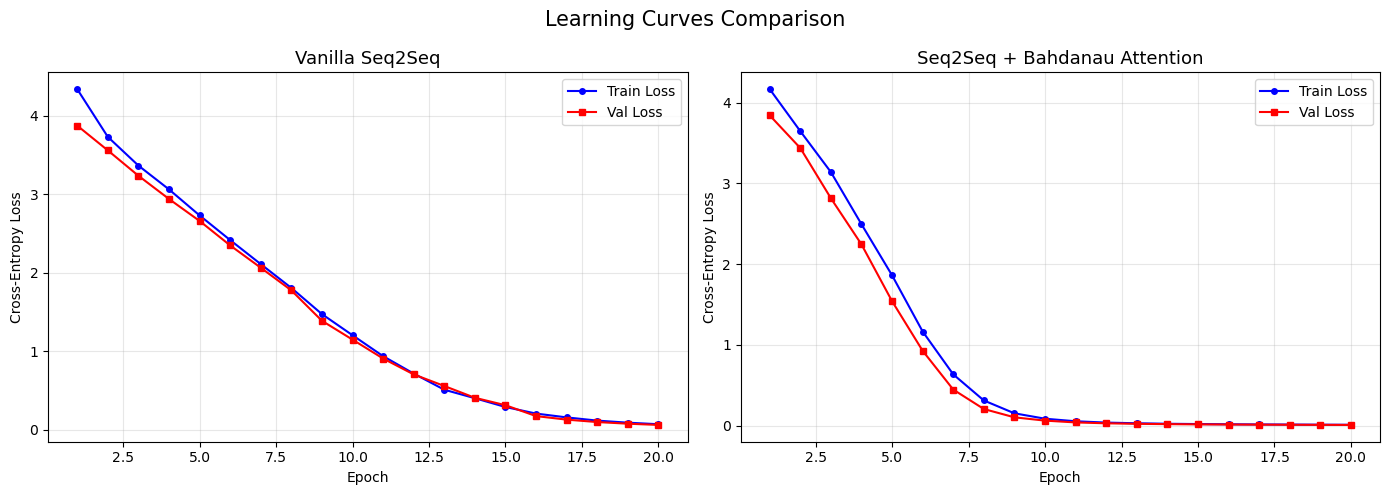

In [26]:
plot_loss_curves(
    vanilla_train_losses, vanilla_val_losses,
    attn_train_losses,    attn_val_losses,
)


### Step 7 — BLEU comparison bar chart

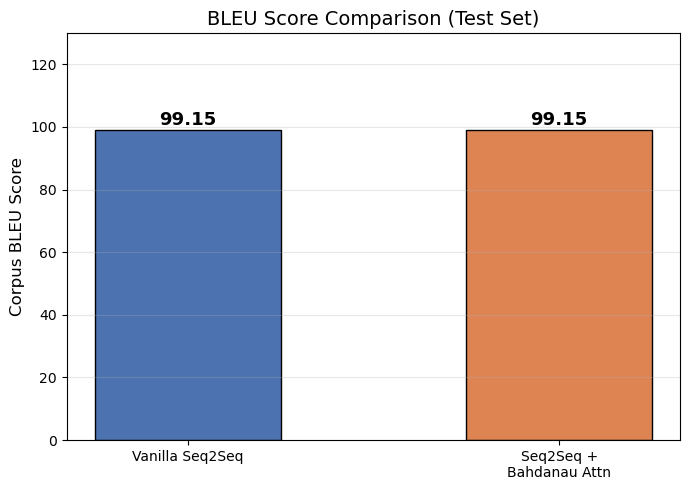

In [27]:
plot_bleu_comparison(vanilla_bleu, attn_bleu)


### Step 8 — Qualitative translation examples

In [28]:
sample_sentences = [
    "a dog is running in the park",
    "a woman reads a book",
    "the sun is shining brightly",
    "the children are laughing",
]

print(f"{'─'*75}")
print(f"{'Source (EN)':<38} {'Vanilla DE':<18} {'Attention DE':<18}")
print(f"{'─'*75}")

attn_sentence, attn_weights, src_toks_for_plot, attn_tgt_toks = None, None, None, None

for sent in sample_sentences:
    van_toks, _          = translate_sentence(
        vanilla_model, sent, src_vocab, tgt_vocab, src_tok_fn, is_attention=False)
    att_toks, att_matrix = translate_sentence(
        attn_model,   sent, src_vocab, tgt_vocab, src_tok_fn, is_attention=True)

    van_str = " ".join(van_toks) or "[empty]"
    att_str = " ".join(att_toks) or "[empty]"
    print(f"{sent:<38} {van_str:<18} {att_str:<18}")

    # Save first result for attention heatmap
    if attn_weights is None and att_matrix is not None:
        attn_sentence     = sent
        attn_weights      = att_matrix
        src_toks_for_plot = [SOS_TOKEN] + src_tok_fn(sent) + [EOS_TOKEN]
        attn_tgt_toks     = att_toks

print(f"{'─'*75}")


───────────────────────────────────────────────────────────────────────────
Source (EN)                            Vanilla DE         Attention DE      
───────────────────────────────────────────────────────────────────────────
a dog is running in the park           ein hund läuft im park ein hund läuft im park
a woman reads a book                   eine frau liest ein buch eine frau liest ein buch
the sun is shining brightly            die sonne scheint hell die sonne scheint hell
the children are laughing              die kinder lachen  die kinder lachen 
───────────────────────────────────────────────────────────────────────────


### Step 9 — Attention heatmap

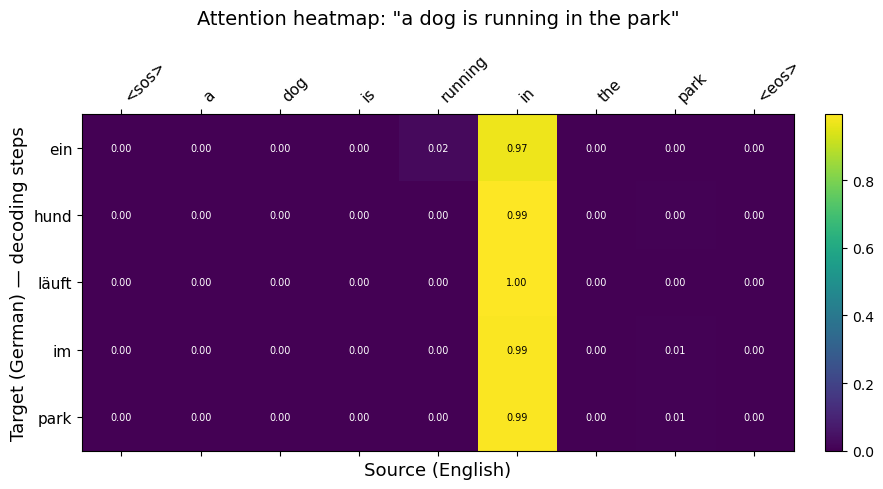

In [29]:
if attn_weights is not None and attn_tgt_toks:
    T_tgt = len(attn_tgt_toks)
    T_src = len(src_toks_for_plot)
    trimmed_attn = attn_weights[:T_tgt, :T_src]   # [T_tgt, T_src]

    plot_attention(
        attention  = trimmed_attn,
        src_tokens = src_toks_for_plot,
        tgt_tokens = attn_tgt_toks,
        title      = f'Attention heatmap: "{attn_sentence}"',
    )
else:
    print("No attention weights available — did the model generate any tokens?")


### Final summary

In [30]:
delta = attn_bleu - vanilla_bleu
sign  = "+" if delta >= 0 else ""

print("\n" + "=" * 60)
print("  RESULTS SUMMARY")
print("=" * 60)
print(f"  Vanilla Seq2Seq BLEU   : {vanilla_bleu:.2f}")
print(f"  Attention Seq2Seq BLEU : {attn_bleu:.2f}")
print(f"  Δ BLEU (Attn − Vanilla): {sign}{delta:.2f}")
print("=" * 60)
print("\nCheckpoints saved:")
print("  best_vanilla_seq2seq.pt")
print("  best_attn_seq2seq.pt")



  RESULTS SUMMARY
  Vanilla Seq2Seq BLEU   : 99.15
  Attention Seq2Seq BLEU : 99.15
  Δ BLEU (Attn − Vanilla): +0.00

Checkpoints saved:
  best_vanilla_seq2seq.pt
  best_attn_seq2seq.pt
